## Punto 2: Selección del número de clusters \(K\) con Elbow y Silhouette (para ambos datasets)

En esta sección determinamos el número de clusters \(K\) más adecuado para los datasets **FIFA 25 Players** y **East West Airlines**. Para ello, probamos varios valores de \(K\) (por ejemplo, de 2 a 10) y comparamos su comportamiento con dos métodos complementarios:

### 1) Método del Codo (Elbow)

- Entrenamos **K-Means** para distintos valores de \(K\) y calculamos la **inercia (SSE)**, que representa la suma de distancias al cuadrado de los puntos a su centroide.  
- Graficamos **Inercia vs. \(K\)** y buscamos el punto donde la mejora deja de ser significativa (el “codo”), lo cual sugiere un balance razonable entre simplicidad y calidad del agrupamiento.

### 2) Análisis de Silhouette

- Para los mismos valores de \(K\), calculamos el **Silhouette Score**.  
- Este indicador evalúa qué tan bien separado y cohesionado está el clustering (valores más altos suelen indicar mejor estructura).  
- Seleccionamos el \(K\) que presente un buen valor de Silhouette y que sea consistente con el resultado del método del codo.

Finalmente, definimos el \(K\) recomendado para cada dataset considerando ambos métodos (Elbow + Silhouette) y justificamos la elección con base en las gráficas y los resultados obtenidos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

In [6]:
df_fifa = pd.read_csv("../GMM/df_FIFA_cleaned_processed.csv")
df_air_raw = pd.read_csv("../GMM/df_EastWestAirlines_processed.csv")
scaler = StandardScaler()
X_fifa = scaler.fit_transform(df_fifa.select_dtypes(include=[np.number]))
X_air_raw = df_air_raw.drop(columns=['ID#', 'Award?'], errors='ignore')
X_air = scaler.fit_transform(X_air_raw.select_dtypes(include=[np.number]))
print("Datasets cargados, preprocesados y escalados correctamente.")
df_fifa.head()

Datasets cargados, preprocesados y escalados correctamente.


,Finishing,Short Passing,Standing Tackle,Sprint Speed,Strength,Dribbling,Crossing,Interceptions,Vision,GK Reflexes
0,1.515166,2.835984,-0.526155,0.869715,0.180269,2.419793,1.440356,-0.334052,2.400562,-0.623331
1,1.515166,1.796169,-0.602847,1.741445,0.753743,1.778358,1.389326,-0.614233,1.562314,0.000000
2,-1.124239,-1.106170,-1.091913,-0.397606,0.753743,-1.663020,-1.337373,-0.866243,0.548278,1.661744
3,1.075732,3.216192,0.270939,0.583747,0.492882,1.778358,1.912162,0.336511,2.334274,0.268810
4,1.243843,2.355368,-0.653585,1.573577,-0.865504,2.336773,1.440356,-0.436236,2.072082,0.000000


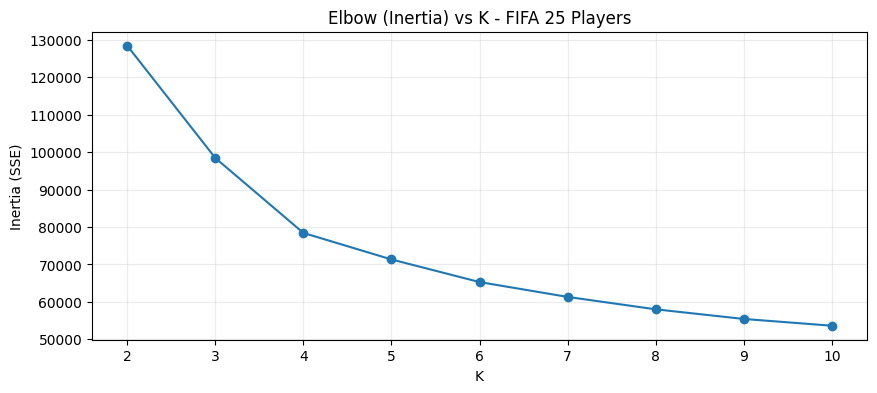

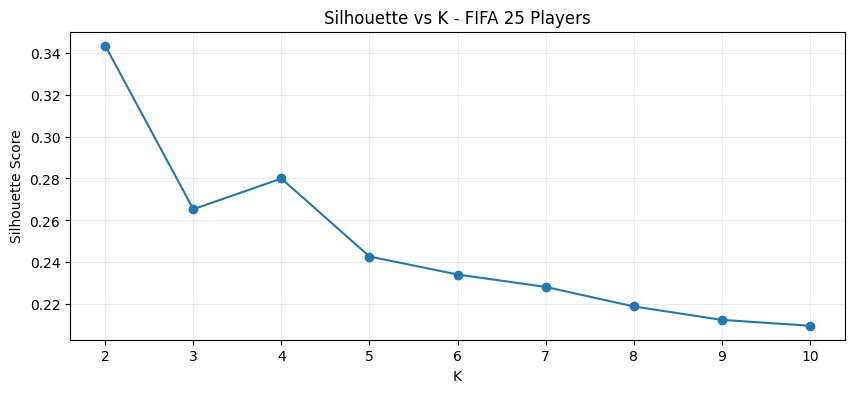

[FIFA 25 Players] K con mayor Silhouette: 2


,K,Inertia (SSE),Silhouette
0,2,128425.225623,0.343269
1,3,98436.497370,0.265341
2,4,78422.048788,0.279985
3,5,71340.035206,0.242801
4,6,65299.333573,0.234226
5,7,61334.524443,0.228311
6,8,58017.443083,0.219011
7,9,55445.525370,0.212604
8,10,53637.420498,0.209812


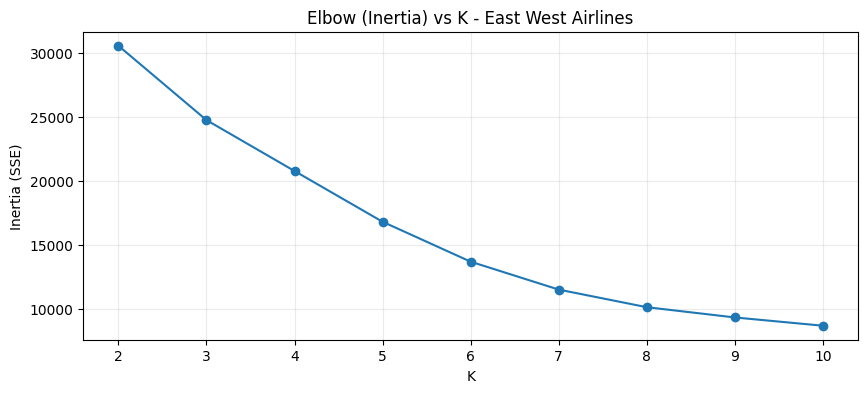

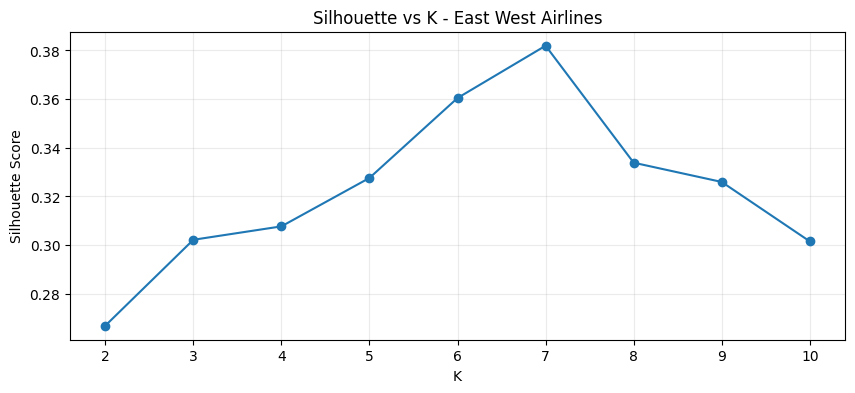

[East West Airlines] K con mayor Silhouette: 7


,K,Inertia (SSE),Silhouette
0,2,30577.536878,0.266848
1,3,24765.310500,0.302170
2,4,20783.543770,0.307683
3,5,16816.013792,0.327586
4,6,13696.087769,0.360437
5,7,11514.054589,0.381934
6,8,10137.999283,0.333852
7,9,9336.607147,0.325939
8,10,8690.345364,0.301510


In [ ]:
def kmeans_elbow_silhouette(X, dataset_name, k_min=2, k_max=10, random_state=42):
    Ks = list(range(k_min, k_max + 1))
    inertias = []
    silhouettes = []
    for k in Ks:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, labels))
    results = pd.DataFrame({"K": Ks,"Inertia (SSE)": inertias,"Silhouette": silhouettes})
    # Elbow plot
    plt.figure(figsize=(10,4))
    plt.plot(results["K"], results["Inertia (SSE)"], marker="o")
    plt.title(f"Elbow (Inertia) vs K - {dataset_name}")
    plt.xlabel("K")
    plt.ylabel("Inertia (SSE)")
    plt.grid(alpha=0.25)
    plt.show()
    # Silhouette plot
    plt.figure(figsize=(10,4))
    plt.plot(results["K"], results["Silhouette"], marker="o")
    plt.title(f"Silhouette vs K - {dataset_name}")
    plt.xlabel("K")
    plt.ylabel("Silhouette Score")
    plt.grid(alpha=0.25)
    plt.show()
    # Recomendación simple por Silhouette (para reportar como referencia)
    k_best_sil = int(results.loc[results["Silhouette"].idxmax(), "K"])
    print(f"[{dataset_name}] K con mayor Silhouette: {k_best_sil}")
    return results

results_fifa = kmeans_elbow_silhouette(X_fifa, "FIFA 25 Players", k_min=2, k_max=10)
display(results_fifa)

results_air = kmeans_elbow_silhouette(X_air, "East West Airlines", k_min=2, k_max=10)
display(results_air)

**Decisión de \(K\):**
- **FIFA 25 Players:** El método del codo sugiere un cambio de pendiente alrededor de \(K=4\). Aunque el Silhouette máximo ocurre en \(K=2\), \(K=4\) ofrece un mejor balance entre calidad del agrupamiento y mayor detalle (más segmentos interpretables). Por ello se selecciona **\(K=4\)**.
- **East West Airlines:** El Silhouette alcanza su valor máximo en **\(K=7\)** y el codo muestra rendimientos decrecientes a partir de ese punto. Por ello se selecciona **\(K=7\)**.

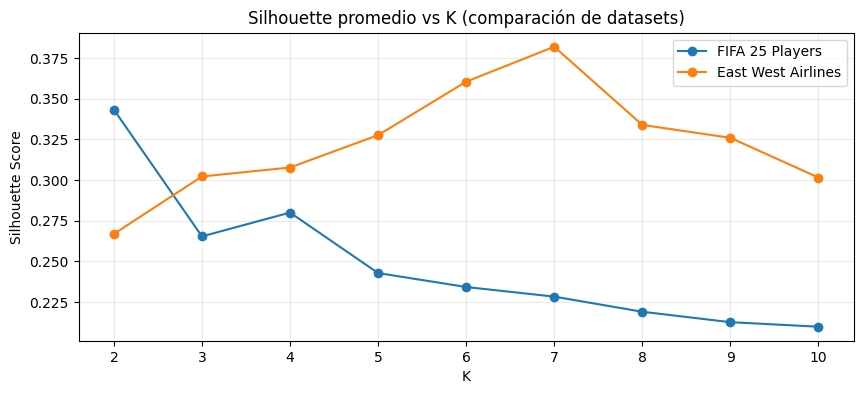

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(results_fifa["K"], results_fifa["Silhouette"], marker="o", label="FIFA 25 Players")
plt.plot(results_air["K"],  results_air["Silhouette"],  marker="o", label="East West Airlines")
plt.title("Silhouette promedio vs K (comparación de datasets)")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

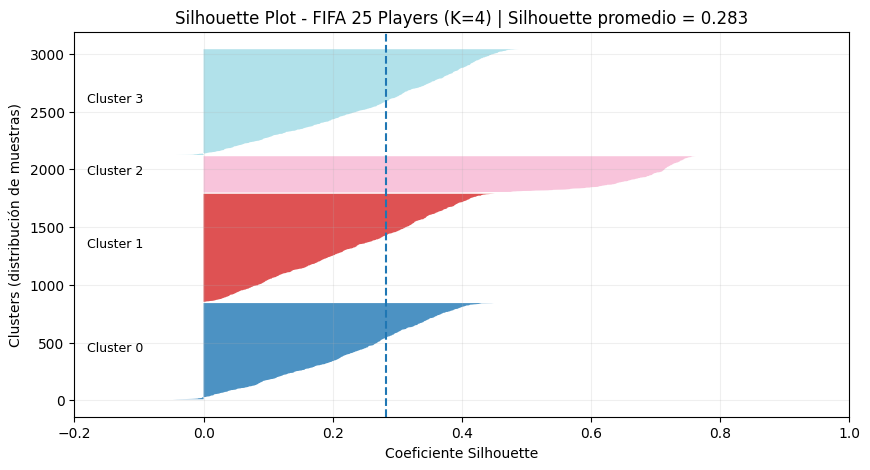

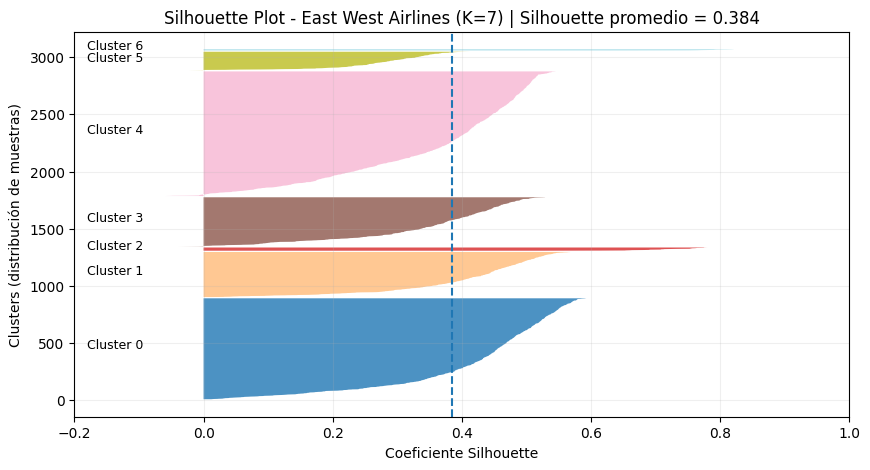

Silhouette promedio (FIFA): 0.283
Silhouette promedio (Airlines): 0.384


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score

def silhouette_cloud_plot(X, labels, title, sample_size=3000, random_state=42, xlim=(-0.2, 1.0)):
    X = np.asarray(X)
    labels = np.asarray(labels)
    n = X.shape[0]

    # Muestreo para acelerar (si el dataset es grande)
    if sample_size is not None and n > sample_size:
        rng = np.random.RandomState(random_state)
        idx = rng.choice(n, size=sample_size, replace=False)
        Xp = X[idx]
        lp = labels[idx]
    else:
        Xp = X
        lp = labels

    sil_avg = silhouette_score(Xp, lp)
    sil_vals = silhouette_samples(Xp, lp)

    clusters = np.unique(lp)
    n_clusters = len(clusters)

    plt.figure(figsize=(10, 5))
    y_lower = 10

    cmap = plt.cm.get_cmap("tab20", n_clusters)  # colores (como lo pediste)

    for i, c in enumerate(clusters):
        vals_c = sil_vals[lp == c]
        vals_c.sort()
        size_c = vals_c.shape[0]
        y_upper = y_lower + size_c

        color = cmap(i)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_c, facecolor=color, alpha=0.8)
        plt.text(xlim[0] + 0.02, y_lower + 0.5 * size_c, f"Cluster {c}", fontsize=9)

        y_lower = y_upper + 10

    # Línea punteada del promedio
    plt.axvline(sil_avg, linestyle="--")
    plt.title(f"{title} | Silhouette promedio = {sil_avg:.3f}")
    plt.xlabel("Coeficiente Silhouette")
    plt.ylabel("Clusters (distribución de muestras)")
    plt.xlim(*xlim)
    plt.grid(alpha=0.2)
    plt.show()

    return sil_avg

from sklearn.cluster import KMeans

K_fifa = 4
K_air  = 7

# FIFA
km_fifa = KMeans(n_clusters=K_fifa, random_state=42, n_init=10)
labels_fifa = km_fifa.fit_predict(X_fifa)
avg_fifa = silhouette_cloud_plot(X_fifa, labels_fifa, f"Silhouette Plot - FIFA 25 Players (K={K_fifa})")

# Airlines
km_air = KMeans(n_clusters=K_air, random_state=42, n_init=10)
labels_air = km_air.fit_predict(X_air)
avg_air = silhouette_cloud_plot(X_air, labels_air, f"Silhouette Plot - East West Airlines (K={K_air})")

print("Silhouette promedio (FIFA):", round(avg_fifa, 3))
print("Silhouette promedio (Airlines):", round(avg_air, 3))

In [14]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ---- Configuración (ajusta si elegiste otros K) ----
K_fifa = 4
K_air  = 7

RANDOM_STATE = 42
SIL_SAMPLE_SIZE = 3000  # para acelerar silhouette si hay muchos datos

def safe_silhouette(X, labels, sample_size=3000, random_state=42):
    """Silhouette con muestreo (para acelerar si el dataset es grande)."""
    X = np.asarray(X)
    labels = np.asarray(labels)
    n = X.shape[0]
    if sample_size is not None and n > sample_size:
        rng = np.random.RandomState(random_state)
        idx = rng.choice(n, size=sample_size, replace=False)
        return silhouette_score(X[idx], labels[idx])
    return silhouette_score(X, labels)

def evaluate_metrics(X, labels, sample_size=3000, random_state=42):
    """4 métricas internas: Silhouette, Davies-Bouldin, Calinski-Harabasz, + (extra se agrega aparte)."""
    return {
        "Silhouette": safe_silhouette(X, labels, sample_size, random_state),
        "Davies-Bouldin": davies_bouldin_score(X, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X, labels),
    }

def fit_kmeans(X, k, random_state=42):
    model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels = model.fit_predict(X)
    return model, labels

def fit_gmm(X, k, random_state=42, covariance_type="full"):
    model = GaussianMixture(
        n_components=k,
        random_state=random_state,
        n_init=10,
        covariance_type=covariance_type
    )
    model.fit(X)
    labels = model.predict(X)
    return model, labels

# ---- Entrenamiento FIFA ----
km_fifa, lab_km_fifa = fit_kmeans(X_fifa, K_fifa, RANDOM_STATE)
gmm_fifa, lab_gmm_fifa = fit_gmm(X_fifa, K_fifa, RANDOM_STATE)

# ---- Entrenamiento Airlines ----
km_air, lab_km_air = fit_kmeans(X_air, K_air, RANDOM_STATE)
gmm_air, lab_gmm_air = fit_gmm(X_air, K_air, RANDOM_STATE)

# ---- Métricas + tabla resumen ----
rows = []

# FIFA - KMeans
m = evaluate_metrics(X_fifa, lab_km_fifa, SIL_SAMPLE_SIZE, RANDOM_STATE)
rows.append({
    "Dataset": "FIFA 25 Players",
    "Modelo": "K-Means",
    "K": K_fifa,
    "Inertia (SSE)": km_fifa.inertia_,
    **m
})

# FIFA - GMM
m = evaluate_metrics(X_fifa, lab_gmm_fifa, SIL_SAMPLE_SIZE, RANDOM_STATE)
rows.append({
    "Dataset": "FIFA 25 Players",
    "Modelo": "GMM",
    "K": K_fifa,
    "BIC": gmm_fifa.bic(X_fifa),
    "AIC": gmm_fifa.aic(X_fifa),
    **m
})

# Airlines - KMeans
m = evaluate_metrics(X_air, lab_km_air, SIL_SAMPLE_SIZE, RANDOM_STATE)
rows.append({
    "Dataset": "East West Airlines",
    "Modelo": "K-Means",
    "K": K_air,
    "Inertia (SSE)": km_air.inertia_,
    **m
})

# Airlines - GMM
m = evaluate_metrics(X_air, lab_gmm_air, SIL_SAMPLE_SIZE, RANDOM_STATE)
rows.append({
    "Dataset": "East West Airlines",
    "Modelo": "GMM",
    "K": K_air,
    "BIC": gmm_air.bic(X_air),
    "AIC": gmm_air.aic(X_air),
    **m
})

summary_metrics = pd.DataFrame(rows)
summary_metrics

,Dataset,Modelo,K,Inertia (SSE),Silhouette,Davies-Bouldin,Calinski-Harabasz,BIC,AIC
0,FIFA 25 Players,K-Means,4,78422.048788,0.282854,1.238201,8820.349150,NaN,NaN
1,FIFA 25 Players,GMM,4,NaN,0.217470,1.518724,7283.448785,283934.437689,281871.367251
2,East West Airlines,K-Means,7,11514.054589,0.383931,0.812120,1645.466897,NaN,NaN
3,East West Airlines,GMM,7,NaN,0.301108,0.959812,1438.365017,-186825.505232,-189726.946852


In [15]:
def cluster_sizes(labels):
    return pd.Series(labels).value_counts().sort_index()

print("FIFA - KMeans tamaños:\n", cluster_sizes(lab_km_fifa), "\n")
print("FIFA - GMM tamaños:\n", cluster_sizes(lab_gmm_fifa), "\n")

print("Airlines - KMeans tamaños:\n", cluster_sizes(lab_km_air), "\n")
print("Airlines - GMM tamaños:\n", cluster_sizes(lab_gmm_air), "\n")

FIFA - KMeans tamaños:
 0    5499
1    5877
2    2063
3    5413
Name: count, dtype: int64 

FIFA - GMM tamaños:
 0    6146
1    5167
2    2055
3    5484
Name: count, dtype: int64 

Airlines - KMeans tamaños:
 0    1148
1     529
2      43
3     574
4    1464
5     223
6      18
Name: count, dtype: int64 

Airlines - GMM tamaños:
 0    1070
1     460
2     224
3    1104
4    1080
5      18
6      43
Name: count, dtype: int64 



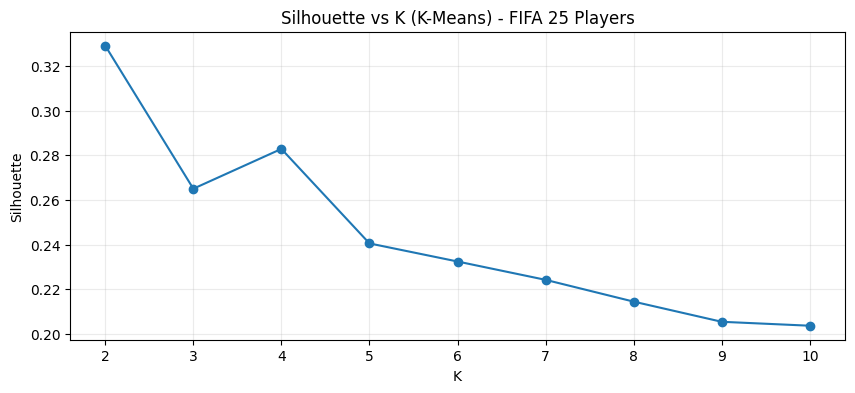

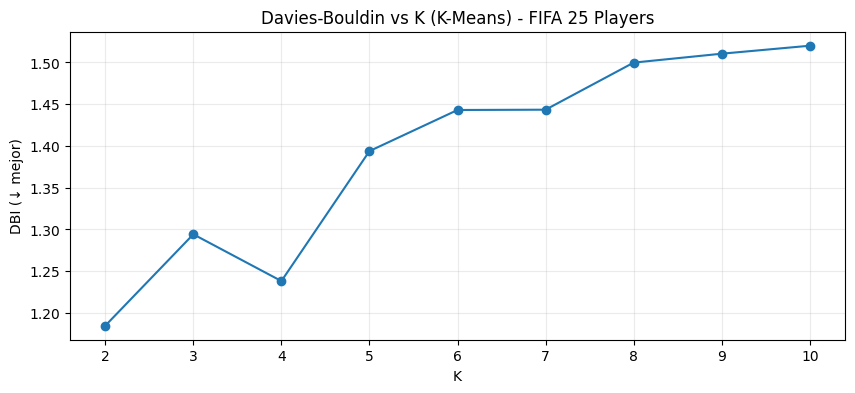

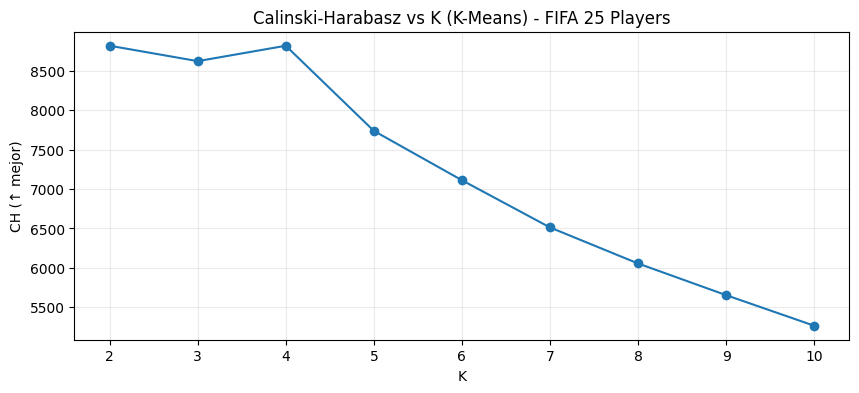

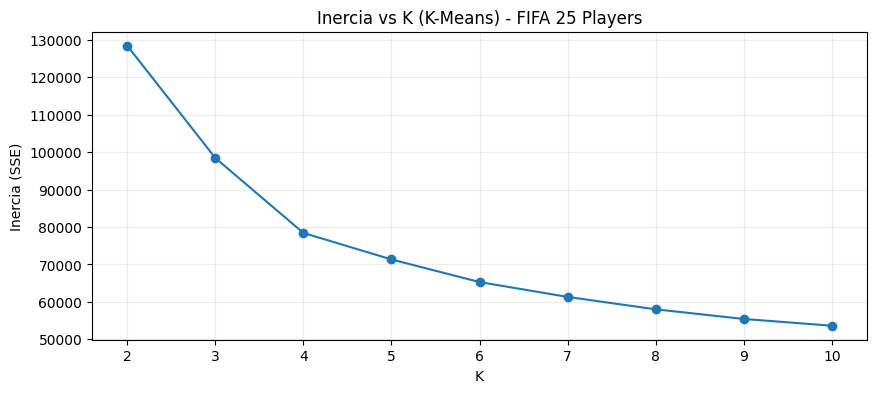

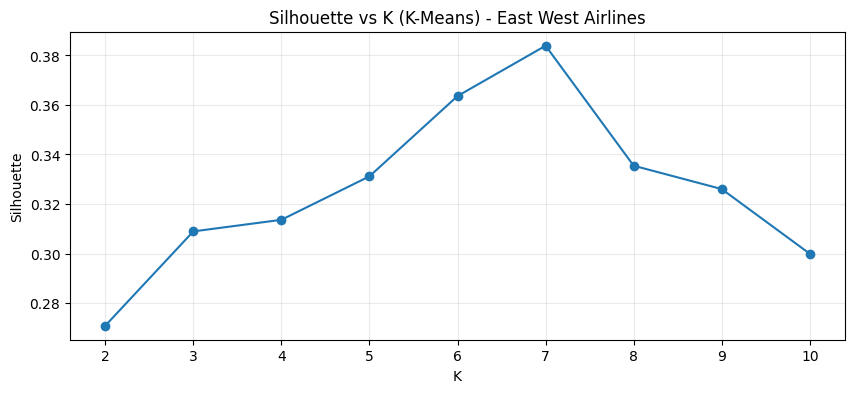

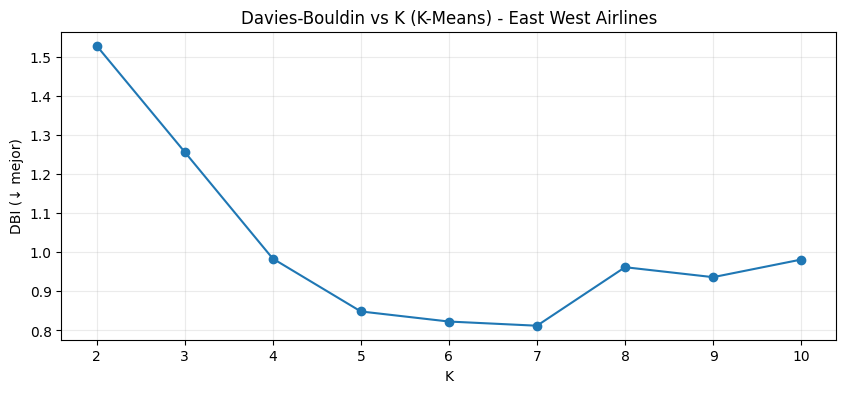

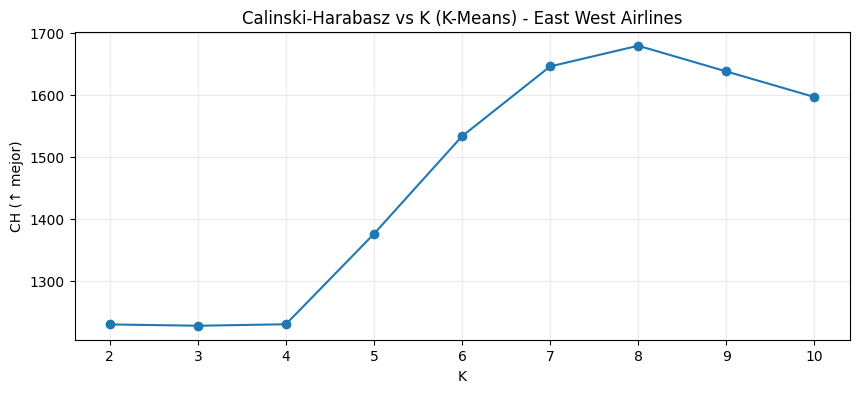

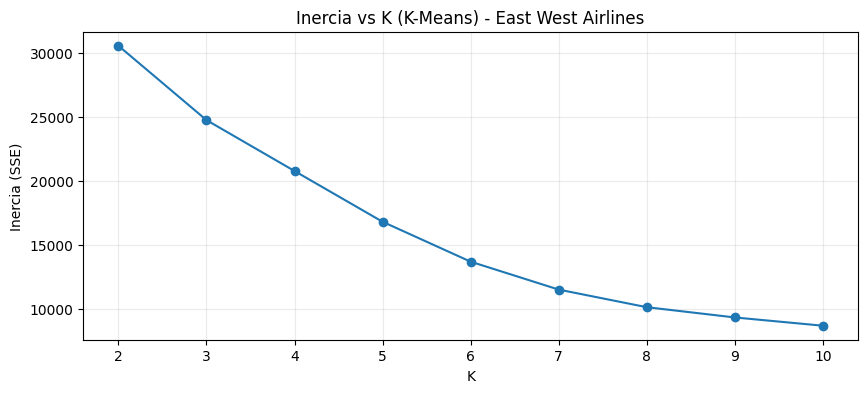

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

def kmeans_metrics_vs_k(X, dataset_name, k_min=2, k_max=10, sample_size=3000, random_state=42):
    Ks = list(range(k_min, k_max+1))
    inertia, sil, dbi, ch = [], [], [], []

    for k in Ks:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = km.fit_predict(X)

        inertia.append(km.inertia_)
        sil.append(safe_silhouette(X, labels, sample_size, random_state))
        dbi.append(davies_bouldin_score(X, labels))
        ch.append(calinski_harabasz_score(X, labels))

    df = pd.DataFrame({"K": Ks, "Inertia": inertia, "Silhouette": sil, "DBI": dbi, "CH": ch})

    # plots
    plt.figure(figsize=(10,4))
    plt.plot(df["K"], df["Silhouette"], marker="o")
    plt.title(f"Silhouette vs K (K-Means) - {dataset_name}")
    plt.xlabel("K"); plt.ylabel("Silhouette"); plt.grid(alpha=0.25); plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(df["K"], df["DBI"], marker="o")
    plt.title(f"Davies-Bouldin vs K (K-Means) - {dataset_name}")
    plt.xlabel("K"); plt.ylabel("DBI (↓ mejor)"); plt.grid(alpha=0.25); plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(df["K"], df["CH"], marker="o")
    plt.title(f"Calinski-Harabasz vs K (K-Means) - {dataset_name}")
    plt.xlabel("K"); plt.ylabel("CH (↑ mejor)"); plt.grid(alpha=0.25); plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(df["K"], df["Inertia"], marker="o")
    plt.title(f"Inercia vs K (K-Means) - {dataset_name}")
    plt.xlabel("K"); plt.ylabel("Inercia (SSE)"); plt.grid(alpha=0.25); plt.show()

    return df

df_k_impact_fifa = kmeans_metrics_vs_k(X_fifa, "FIFA 25 Players", 2, 10, SIL_SAMPLE_SIZE, RANDOM_STATE)
df_k_impact_air  = kmeans_metrics_vs_k(X_air, "East West Airlines", 2, 10, SIL_SAMPLE_SIZE, RANDOM_STATE) 

## Conclusiones (K-Means) — Selección de \(K\) e impacto en las métricas

En esta sección se evaluó el número de clusters \(K\) para **FIFA 25 Players** y **East West Airlines** usando **Elbow (Inercia)** y métricas internas de validación: **Silhouette**, **Davies–Bouldin (DBI)** y **Calinski–Harabasz (CH)**.  
> Nota: **la inercia siempre disminuye** al aumentar \(K\); por eso se complementa con Silhouette/DBI/CH para evitar escoger un \(K\) demasiado grande sin ganancia real en calidad.

---

### 1) FIFA 25 Players (K-Means)

**Comportamiento observado:**
- **Silhouette**: el valor más alto ocurre en **\(K=2\)** (mejor separación global con pocos grupos). En **\(K=4\)** hay un valor relativamente bueno (segundo mejor), y a partir de \(K \ge 5\) la calidad **tiende a disminuir**.
- **DBI (↓ mejor)**: el mejor (más bajo) también se observa alrededor de **\(K=2\)**. Después, el DBI tiende a **aumentar**, lo que sugiere mayor solapamiento entre clusters para \(K\) más grandes.
- **CH (↑ mejor)**: presenta valores altos en **\(K=2\)** y también un valor competitivo en **\(K=4\)**; luego decrece conforme aumenta \(K\).
- **Inercia**: disminuye fuertemente de \(K=2\) a \(K=4\) y luego las mejoras son **más marginales**, sugiriendo un “codo” cerca de **\(K \approx 4\)**.

**Recomendación de \(K\):**
- Si se prioriza **máxima separación y cohesión** (mejor calidad geométrica): **\(K=2\)**.
- Si se busca un balance entre **interpretabilidad (más segmentos)** y calidad aceptable (respaldado por el “codo” e indicadores razonables): **\(K=4\)**.

✅ **Elección recomendada para el notebook:** **\(K=4\)** como compromiso práctico (codo claro + métricas aún competitivas), dejando documentado que \(K=2\) maximiza Silhouette.

---

### 2) East West Airlines (K-Means)

**Comportamiento observado:**
- **Silhouette**: incrementa hasta alcanzar un pico claro en **\(K=7\)** y luego cae (para \(K \ge 8\)), lo que sugiere que **\(K=7\)** captura una estructura natural.
- **DBI (↓ mejor)**: disminuye sostenidamente y alcanza su mínimo en **\(K=7\)**; después vuelve a subir, indicando deterioro en separación al aumentar más \(K\).
- **CH (↑ mejor)**: crece con \(K\) y alcanza su máximo cerca de **\(K=8\)**, aunque **\(K=7\)** permanece muy cercano a ese máximo.
- **Inercia**: se reduce con \(K\), con rendimientos decrecientes alrededor de \(K \approx 6\)–\(8\).

**Recomendación de \(K\):**
✅ **\(K=7\)** es la mejor elección global porque:
- Maximiza **Silhouette**,
- Minimiza **DBI**,
- Mantiene un valor **alto** de **CH** (muy cercano al máximo),
- Y es consistente con la zona de rendimientos decrecientes en inercia.

---

### 3) Impacto de la elección de \(K\) en las métricas (resumen general)

- **Inercia (SSE):** siempre **↓** al aumentar \(K\). Es útil para ver el “codo”, pero por sí sola tiende a favorecer \(K\) grandes.
- **Silhouette:** suele subir hasta un \(K\) óptimo y luego **↓** si los clusters se fragmentan o se solapan (se ve claro en Airlines: pico en \(K=7\)).
- **DBI:** suele **↓** hasta un mínimo (mejor) y puede **↑** después si se crean clusters demasiado similares/solapados (en Airlines el mínimo está en \(K=7\)).
- **CH:** tiende a favorecer soluciones con buena separación relativa; puede crecer hasta cierto punto y luego estabilizarse o caer. Por eso se interpreta junto a Silhouette y DBI.

---

### 4) Recomendación final (K-Means)

- **FIFA 25 Players:** **\(K=4\)** (compromiso entre el codo en inercia y métricas competitivas; \(K=2\) queda como alternativa si se prioriza máxima separación).
- **East West Airlines:** **\(K=7\)** (mejor desempeño simultáneo en Silhouette y DBI, y CH alto).

---
